# Preet's Contribution

Model Tuning

In [45]:
def train_model(encoder, decoder, denoiser, dataloader, noise_scale, epochs, save_name):
    import time
    from tqdm import tqdm

    encoder.to(device)
    decoder.to(device)
    denoiser.to(device)

    loss_fn = nn.MSELoss()
    optimizer = optim.Adam(
        list(encoder.parameters()) +
        list(decoder.parameters()) +
        list(denoiser.parameters()),
        lr=1e-4
    )

    for epoch in range(epochs):
        start_time = time.time()
        total_loss = 0.0
        total_recon_loss = 0.0
        total_denoise_loss = 0.0

        loop = tqdm(dataloader, desc=f"Epoch {epoch+1}", leave=False)

        for imgs, _ in loop:
            imgs = imgs.to(device)
            latents = encoder(imgs)

            noise = torch.randn_like(latents)
            noisy_latents = latents + noise * noise_scale

            predicted_noise = denoiser(noisy_latents, torch.tensor([0]).to(device))
            loss_denoise = loss_fn(predicted_noise, noise)

            decoded_imgs = decoder(latents)
            loss_recon = loss_fn(decoded_imgs, imgs)

            loss = loss_denoise + loss_recon

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_denoise_loss += loss_denoise.item()
            total_recon_loss += loss_recon.item()

            loop.set_postfix({
                "Loss": f"{loss.item():.4f}",
                "Recon": f"{loss_recon.item():.4f}",
                "Denoise": f"{loss_denoise.item():.4f}"
            })

        elapsed_time = time.time() - start_time
        avg_loss = total_loss / len(dataloader)
        avg_recon = total_recon_loss / len(dataloader)
        avg_denoise = total_denoise_loss / len(dataloader)

        print(f"Epoch {epoch+1} Completed | Time: {elapsed_time:.2f}s | "
              f"Avg Loss: {avg_loss:.4f} | Recon: {avg_recon:.4f} | Denoise: {avg_denoise:.4f}")

    # Save the model
    torch.save({
        'encoder': encoder.state_dict(),
        'decoder': decoder.state_dict(),
        'denoiser': denoiser.state_dict(),
        'optimizer': optimizer.state_dict()
    }, f"{save_name}.pth")

    print(f"✔ Model saved to {save_name}.pth")

Model Tuning Round 1

In [47]:
train_model(
    encoder, decoder, denoiser,
    dataloader=dataloader,
    noise_scale=0.05,
    epochs=50,
    save_name="ldm_round1"
)

Epoch 1 Completed | Time: 38.23s | Avg Loss: 1.0838 | Recon: 0.0839 | Denoise: 0.9999


Epoch 2 Completed | Time: 37.62s | Avg Loss: 1.0567 | Recon: 0.0568 | Denoise: 0.9999


Epoch 3 Completed | Time: 37.55s | Avg Loss: 1.0461 | Recon: 0.0461 | Denoise: 1.0001


Epoch 4 Completed | Time: 37.44s | Avg Loss: 1.0398 | Recon: 0.0399 | Denoise: 0.9999


Epoch 5 Completed | Time: 37.48s | Avg Loss: 1.0355 | Recon: 0.0356 | Denoise: 0.9999


...

Epoch 46 Completed | Time: 37.25s | Avg Loss: 1.0101 | Recon: 0.0103 | Denoise: 0.9999


Epoch 47 Completed | Time: 37.36s | Avg Loss: 1.0099 | Recon: 0.0100 | Denoise: 0.9999


Epoch 48 Completed | Time: 37.38s | Avg Loss: 1.0100 | Recon: 0.0100 | Denoise: 1.0000


Epoch 49 Completed | Time: 37.58s | Avg Loss: 1.0099 | Recon: 0.0097 | Denoise: 1.0002


Epoch 50 Completed | Time: 37.25s | Avg Loss: 1.0100 | Recon: 0.0100 | Denoise: 1.0000
✔ Model saved to ldm_round1.pth


Model Tuning Round 2

In [48]:
train_model(
    encoder, decoder, denoiser,
    dataloader=dataloader,
    noise_scale=0.5,
    epochs=50,
    save_name="ldm_round2"
)

Epoch 1 Completed | Time: 37.73s | Avg Loss: 1.0157 | Recon: 0.0157 | Denoise: 1.0000


Epoch 2 Completed | Time: 36.95s | Avg Loss: 1.0093 | Recon: 0.0093 | Denoise: 1.0000


Epoch 3 Completed | Time: 37.30s | Avg Loss: 1.0094 | Recon: 0.0093 | Denoise: 1.0001


Epoch 4 Completed | Time: 38.26s | Avg Loss: 1.0092 | Recon: 0.0092 | Denoise: 1.0000


Epoch 5 Completed | Time: 37.30s | Avg Loss: 1.0091 | Recon: 0.0093 | Denoise: 0.9999


...

Epoch 46 Completed | Time: 37.15s | Avg Loss: 1.0066 | Recon: 0.0065 | Denoise: 1.0001


Epoch 47 Completed | Time: 37.07s | Avg Loss: 1.0064 | Recon: 0.0065 | Denoise: 0.9999


Epoch 48 Completed | Time: 37.10s | Avg Loss: 1.0066 | Recon: 0.0066 | Denoise: 1.0000


Epoch 49 Completed | Time: 37.05s | Avg Loss: 1.0064 | Recon: 0.0064 | Denoise: 1.0001


Epoch 50 Completed | Time: 37.48s | Avg Loss: 1.0065 | Recon: 0.0063 | Denoise: 1.0001
✔ Model saved to ldm_round2.pth


Image Generation for Tuning

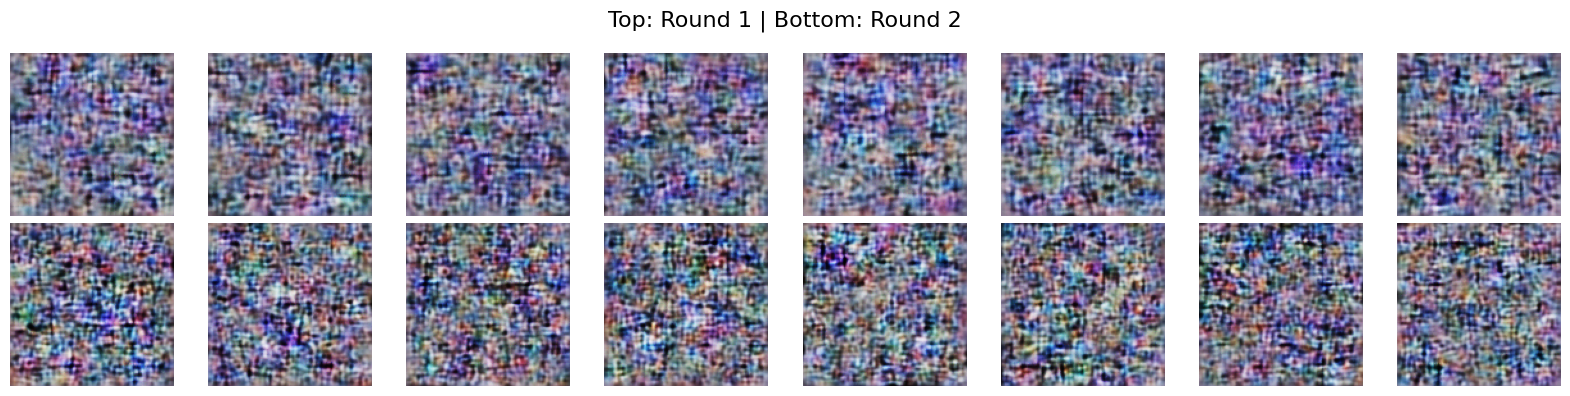

In [50]:
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

def show_comparison(gen1, gen2, n=8):
    """
    Display n images from Round 1 and Round 2 side-by-side.
    """
    to_pil = transforms.ToPILImage()
    fig, axs = plt.subplots(2, n, figsize=(n * 2, 4))
    fig.suptitle("Top: Round 1 | Bottom: Round 2", fontsize=16)

    for i in range(n):
        axs[0, i].imshow(to_pil(gen1[i].cpu()))
        axs[0, i].axis('off')
        axs[1, i].imshow(to_pil(gen2[i].cpu()))
        axs[1, i].axis('off')

    plt.tight_layout()
    plt.show()

# Load models
encoder1, decoder1, _ = load_model_from_ckpt("ldm_round1.pth")
encoder2, decoder2, _ = load_model_from_ckpt("ldm_round2.pth")

# Generate 16 images from each
gen_imgs1 = generate_images(decoder1, n=16)
gen_imgs2 = generate_images(decoder2, n=16)

# Visualize side-by-side (first 8)
show_comparison(gen_imgs1, gen_imgs2, n=8)

LLM Prompts:

*   How does tuning the noise scale affect the model's ability to generate diverse images?
*   Give code to comapre the generated images for each round of tuning.